# CLTV article
These plots will be used for an article about CLTV.

In [3]:
import pandas as pd
import numpy as np
from plotly_presentation import Plotter, Analysis

In [29]:
n = 1000
customers = pd.DataFrame(
    {
        "customer_id": np.arange(1, n+1),
        "engagement_score": np.random.normal(loc=0.5, scale=0.5/3, size=n).clip(0, 1),
        "revenue": np.random.choice([10, 15, 25], size=n, p=[0.5, 0.3, 0.2]),
    }
)
customers["cost"] = -customers["engagement_score"] * 10 + np.random.normal(-2, 0.3, size=customers.shape[0]) - np.random.uniform(0.05, 0.15, size=customers.shape[0]) * customers["revenue"]
customers["monthly_churn_probability"] = 0.2 - customers["engagement_score"] * (0.2 - 0.01) + np.random.normal(0, 0.05, size=customers.shape[0])
customers["monthly_churn_probability"] = customers["monthly_churn_probability"].clip(0.02, 1)
customers["gross_profit"] = customers["revenue"] + customers["cost"]
customers["cltv"] = customers["gross_profit"] / customers["monthly_churn_probability"]
customers["cltv_clipped"] = customers["cltv"].clip(-50, 300)
customers["top_gross_profit"] = customers["gross_profit"].rank(ascending=False, method="first") <= 0.2 * n
customers["top_cltv"] = customers["cltv"].rank(ascending=False, method="first") <= 0.2 * n
customers.describe()

,customer_id,engagement_score,revenue,cost,monthly_churn_probability,gross_profit,cltv,cltv_clipped
count,1000.000000,1000.000000,1000.00000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,500.500000,0.500530,14.45000,-8.428057,0.108101,6.021943,74.872377,66.052003
std,288.819436,0.165602,5.76461,1.814966,0.053116,5.481608,111.818496,72.995010
min,1.000000,0.000000,10.00000,-15.696606,0.020000,-3.169244,-67.031973,-50.000000
25%,250.750000,0.396060,10.00000,-9.639031,0.068638,1.883995,17.213128,17.213128
50%,500.500000,0.502142,10.00000,-8.351256,0.106770,4.174631,41.961940,41.961940
75%,750.250000,0.612667,15.00000,-7.245990,0.146677,8.114557,93.474059,93.474059
max,1000.000000,1.000000,25.00000,-2.824520,0.277398,21.876192,800.108961,300.000000


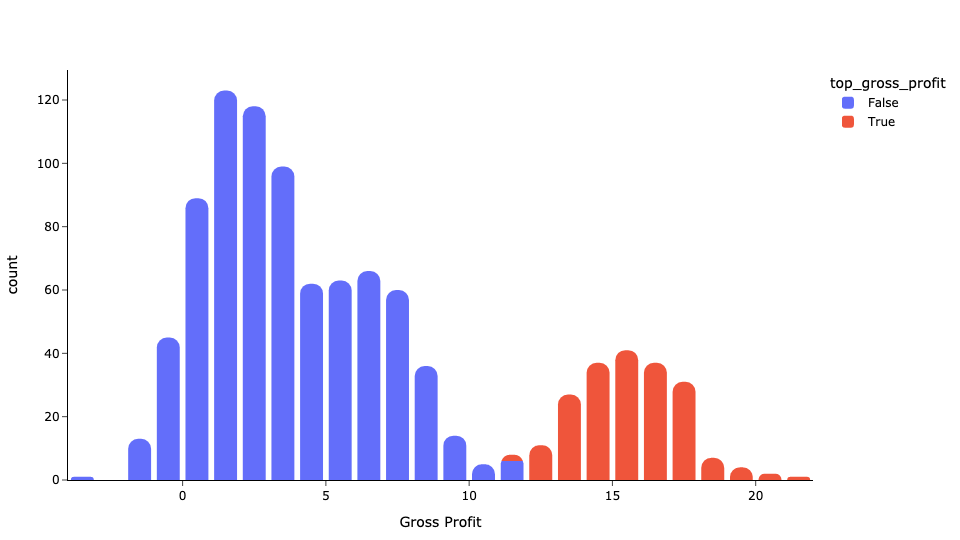

In [30]:
p = Plotter()
p.express(
    type="histogram",
    data_frame=customers,
    x="gross_profit",
    nbins=30,
    labels={
        "gross_profit": "Gross Profit",
        "engagement_score": "Engagement Score",
        "revenue": "Revenue",
        "cost": "Cost",
        "monthly_churn_probability": "Monthly Churn Probability",
        "cltv": "Customer Lifetime Value (CLTV)",
        "cltv_clipped": "CLTV (Clipped)",
    },
    color = "top_gross_profit",
    color_discrete_sequence=["#636EFA", "#EF553B"],
)
p.show()

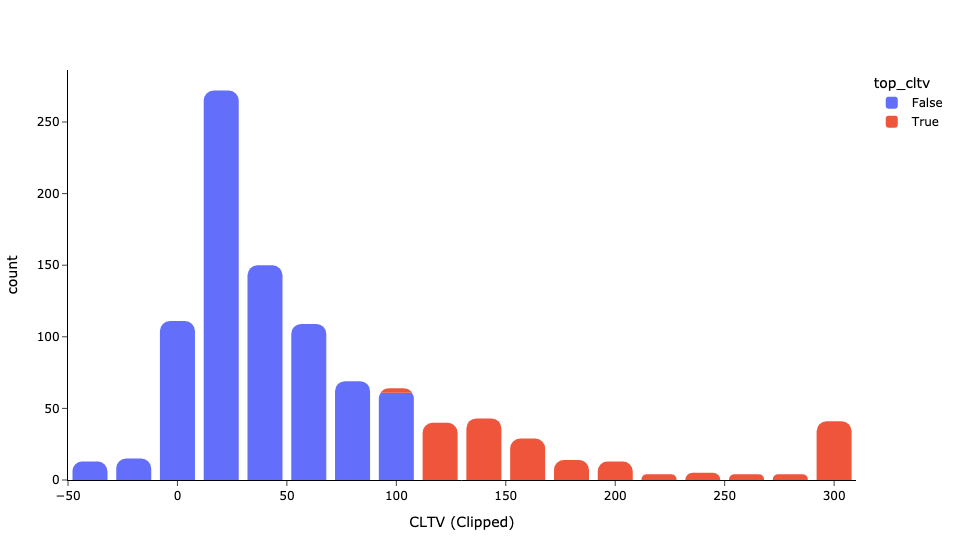

In [32]:
p = Plotter()
p.express(
    type="histogram",
    data_frame=customers,
    x="cltv_clipped",
    nbins=30,
    labels={
        "gross_profit": "Gross Profit",
        "engagement_score": "Engagement Score",
        "revenue": "Revenue",
        "cost": "Cost",
        "monthly_churn_probability": "Monthly Churn Probability",
        "cltv": "Customer Lifetime Value (CLTV)",
        "cltv_clipped": "CLTV (Clipped)",
    },
    color = "top_cltv",
    color_discrete_sequence=["#636EFA", "#EF553B"],
)
p.show()

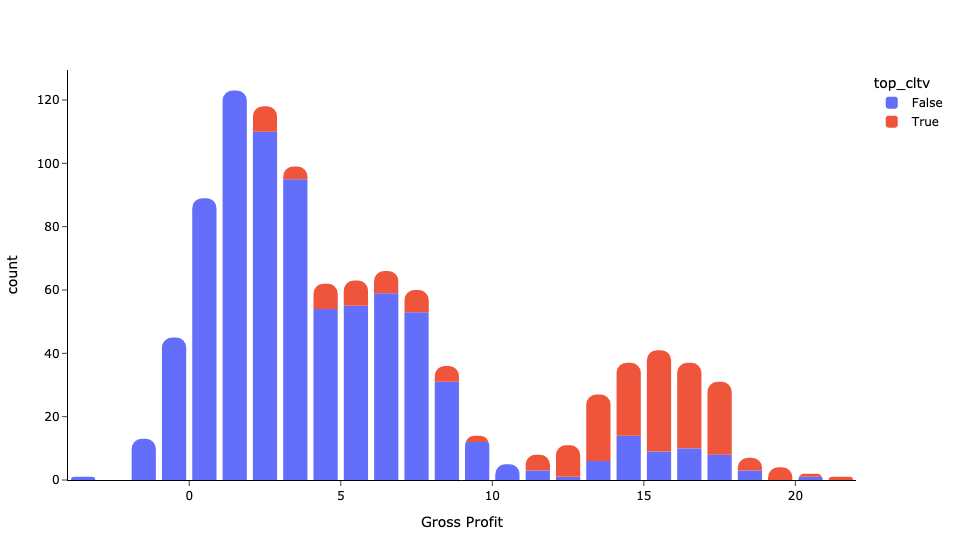

In [33]:
p = Plotter()
p.express(
    type="histogram",
    data_frame=customers,
    x="gross_profit",
    nbins=30,
    labels={
        "gross_profit": "Gross Profit",
        "engagement_score": "Engagement Score",
        "revenue": "Revenue",
        "cost": "Cost",
        "monthly_churn_probability": "Monthly Churn Probability",
        "cltv": "Customer Lifetime Value (CLTV)",
        "cltv_clipped": "CLTV (Clipped)",
    },
    color = "top_cltv",
    color_discrete_sequence=["#636EFA", "#EF553B"],
)
p.show()